# 多品种绩效对比 — 不同训练截止日期

对比 **2025-01-01** 和 **2025-07-01** 两个训练截止日期训练的模型，
在统一回测窗口（2025-07-01 以后）的表现。


In [1]:
# ==================== 全局配置 ====================
SYMBOLS = ["A", "B", "C", "CS", "M", "P", "LH"]  # Y 缺少 2026-01-01 模型
TRAIN_END_DATES = ["2025-01-01", "2025-07-01", "2026-01-01"]   # 要对比的三个训练截止日期
VERSIONS = ["v0"]                                # 固定版本

train_label = 5
bt_start = "2026-01-01"   # 统一从 2026-01-01 开始回测（公共样本外窗口）
bt_end = "2026-05-07"     # 回测结束日期

bt_params = {
    "th1": 0.9, "th2": 0.5, "holding_bars": 10,
    "holding_days": 5, "fee": 0, "v": 2,
}

# 模型根目录（生产环境统一存放位置）
model_base_dir = "/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models"
output_dir = "./eval_three_dates"


In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("/home/future_commodity")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_symbol_eval import MultiSymbolEvaluator


In [3]:
ev = MultiSymbolEvaluator(
    model_base_dir=model_base_dir,
    bt_start=bt_start, bt_end=bt_end,
    bt_params=bt_params, output_dir=output_dir, money="auto",
)

ev.run_batch(
    symbols=SYMBOLS, train_end_dates=TRAIN_END_DATES,
    versions=VERSIONS, train_label=train_label,
    n_jobs=8,
)


并行回测: 16 组任务, n_jobs=8


回测进度: 100%|██████████| 16/16 [1:07:50<00:00, 254.42s/it]


In [4]:
summary = ev.get_summary_df()
summary


,symbol,train_end_date,version,annual_ret,sharpe,max_dd,win_rate,trade_count,avg_position,long_contrib,short_contrib,days,start_date,end_date
0,A,2025-07-01,v0,0.003668,1.081944,-0.180632,0.558252,5588,0.420443,-0.010272,-0.013009,206,2025-07-01,2026-07-01
1,A,2025-01-01,v0,0.002040,0.633246,-0.198004,0.582524,3847,0.412398,-0.005216,-0.007161,206,2025-07-01,2026-07-01
2,B,2025-07-01,v0,0.012553,4.181867,-0.117725,0.606796,5741,0.416777,-0.003175,0.001614,206,2025-07-01,2026-07-01
3,B,2025-01-01,v0,0.009032,3.147295,-0.145528,0.572816,6146,0.425806,-0.004560,-0.001648,206,2025-07-01,2026-07-01
4,C,2025-07-01,v0,0.013116,10.241840,-0.024934,0.752427,7955,0.402941,-0.003093,-0.003289,206,2025-07-01,2026-07-01
5,C,2025-01-01,v0,0.012229,9.528316,-0.038246,0.723301,7359,0.403583,-0.003181,-0.003378,206,2025-07-01,2026-07-01
6,CS,2025-07-01,v0,0.007854,5.081504,-0.063840,0.674757,8743,0.394069,-0.008992,-0.009736,206,2025-07-01,2026-07-01
7,CS,2025-01-01,v0,0.005929,4.098797,-0.048304,0.635922,8662,0.400217,-0.009931,-0.010141,206,2025-07-01,2026-07-01
8,LH,2025-07-01,v0,0.107709,5.743640,-0.352863,0.658537,3815,0.407378,-0.004011,-0.015445,205,2025-07-01,2026-07-01
9,LH,2025-01-01,v0,0.106528,5.274008,-0.571822,0.639024,3925,0.415599,0.014956,0.001453,205,2025-07-01,2026-07-01


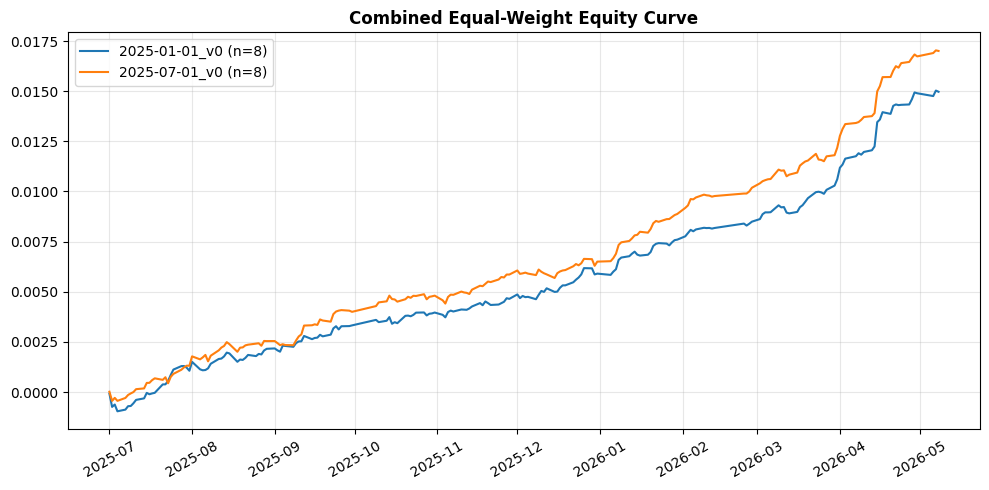

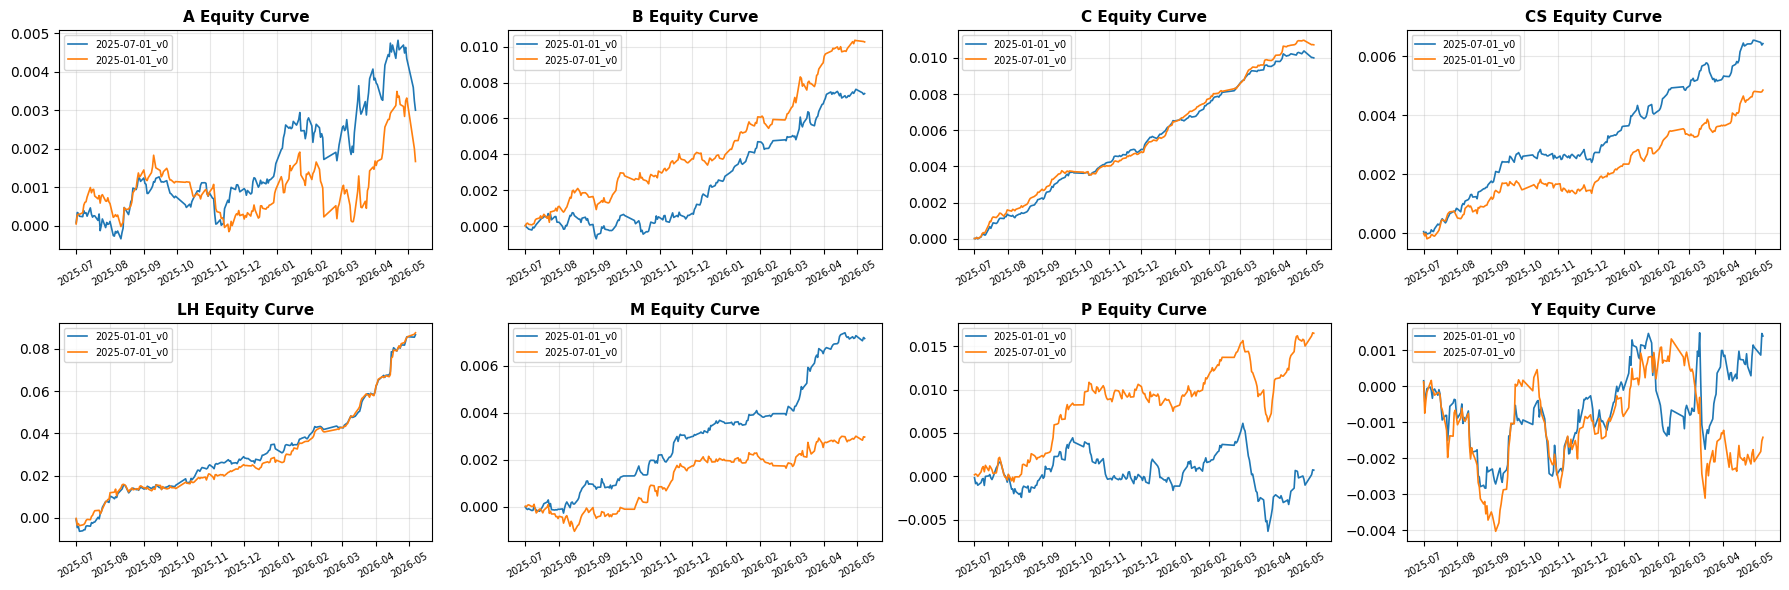

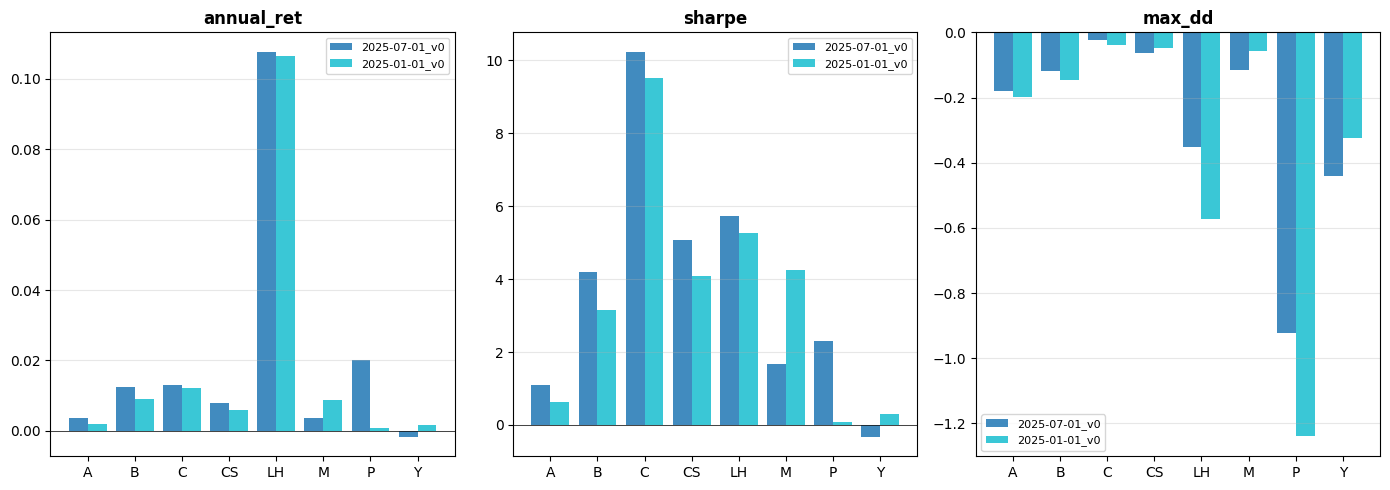

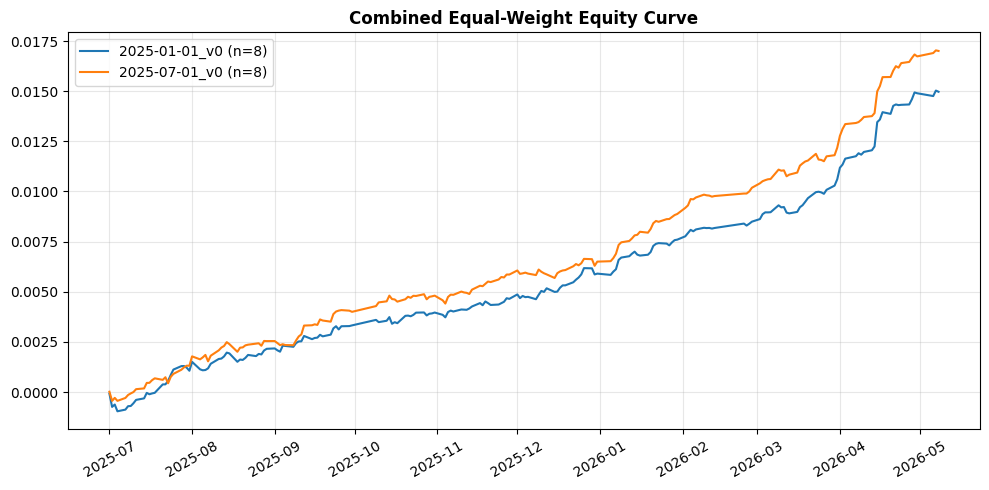

In [5]:
ev.save_summary_csv()
ev.plot_equity_curves()
ev.plot_metrics_bar()
ev.plot_combined_equity()
